Import the required libraries


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

load the data

In [4]:
from sklearn.datasets import load_breast_cancer
X,y =load_breast_cancer(return_X_y=True)

shape

In [5]:
X.shape

(569, 30)

In [3]:
y.shape

(569,)

Data Splitting & Model Training

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

/home/anuj/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Probabilities of the test set for class 1

In [13]:
# probability only for the class 1
y_prob_lr = model.predict_proba(X_test)[:,1]
y_prob_lr

array([8.84967736e-01, 1.08735112e-09, 2.99295934e-03, 9.97302354e-01,
       9.98960156e-01, 1.01967440e-10, 1.12413716e-13, 3.87023636e-03,
       9.97964021e-01, 9.89699398e-01, 9.60555128e-01, 1.50651311e-04,
       9.92303839e-01, 3.63822889e-01, 9.96762859e-01, 4.77743680e-04,
       9.98062793e-01, 9.99830685e-01, 9.96724646e-01, 6.06276901e-08,
       8.86338532e-01, 9.70995296e-01, 5.98383442e-10, 9.95802752e-01,
       9.92217401e-01, 9.99497765e-01, 9.97804893e-01, 9.96150096e-01,
       9.94055348e-01, 9.60320637e-09, 9.97072771e-01, 9.98545389e-01,
       9.78554723e-01, 9.91520017e-01, 9.98667452e-01, 9.97873221e-01,
       1.50125113e-03, 9.90321779e-01, 1.70058389e-06, 9.17961687e-01,
       9.98584280e-01, 8.89513354e-04, 9.99377150e-01, 9.92640123e-01,
       9.98307636e-01, 9.62310100e-01, 9.98857231e-01, 9.90881542e-01,
       9.27248029e-01, 9.96848763e-01, 7.42367027e-05, 2.06084751e-10,
       9.58926412e-01, 9.98253143e-01, 9.99366635e-01, 9.87419246e-01,
      

In [14]:
#predicting the class labels
y_pred_lr = model.predict(X_test)
y_pred_lr

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0])

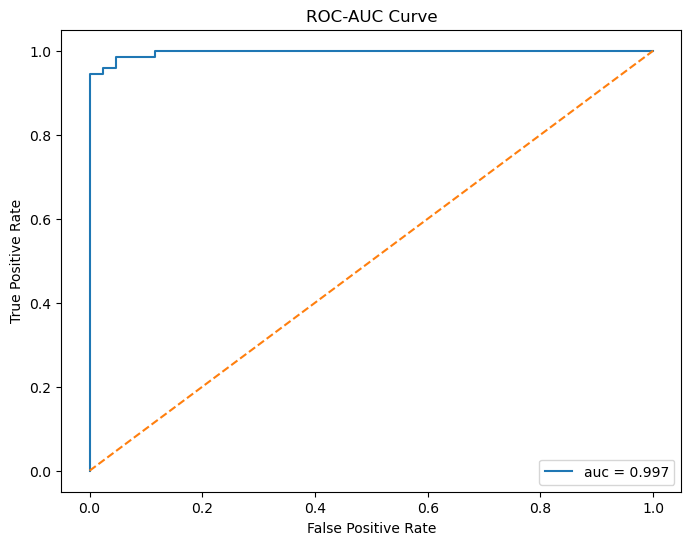

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC evaluates the performance of the model across multiple thresholds using probabilities
fpr, tpr, threshold = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

# plot roc-auc curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'auc = {auc_score:.3f}')

# random model line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.show()

In [17]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[40,  3],
       [ 1, 70]])

In [18]:
tn, fp, fn, tp = cm.ravel()
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 40
False Positives (FP): 3
False Negatives (FN): 1
True Positives (TP): 70


Visualize the confusion matrix

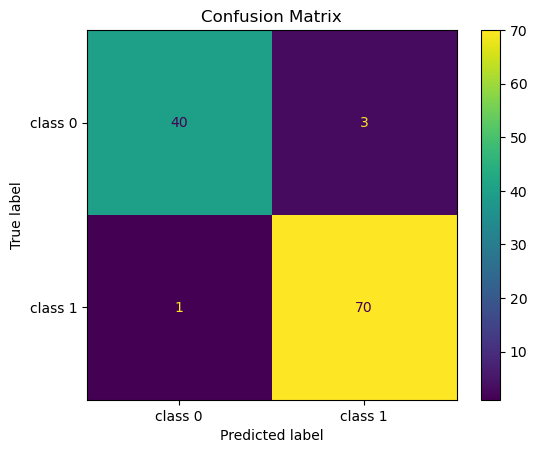

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['class 0', 'class 1'])
display.plot()
plt.title('Confusion Matrix')
plt.show()

Impact of different threshold on Confusion Matrix

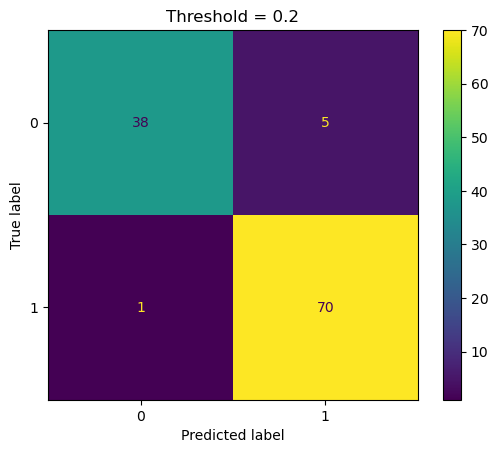

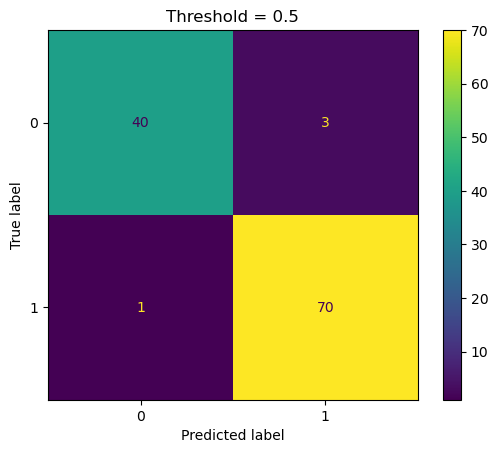

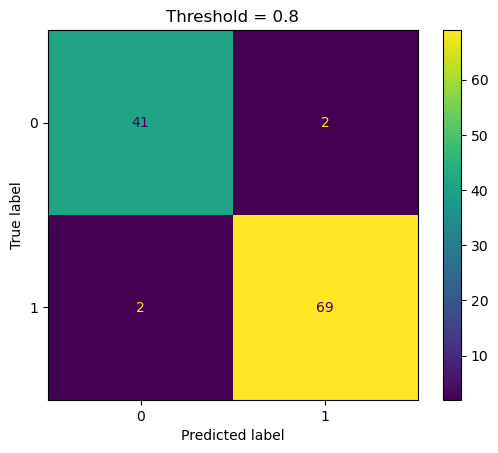

In [22]:
thresholds = [0.2, 0.5, 0.8]
# 0.2 => recall increases because FN values are 0
# 0.8 => precision increases because FP values are 0
y_prob = model.predict_proba(X_test)[:,1]

for threshold in thresholds:
  y_pred = (y_prob >= threshold).astype(int)
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

  disp.plot()
  plt.title(f"Threshold = {threshold}")
  plt.show()